In [1]:
# Load necessary library
library(fs)
library("ggplot2")

# Required library for rolling mean
library(zoo)  # Install if needed: install.packages("zoo")
library(reshape2,lib.loc="/data/proj2/home/students/u.srinivasan/R/library")
library(dplyr)




Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




load fixed r files

In [2]:
#Define mutation rate and generation time
mu <- 4.0425e-09
gen <- 0.16

# Initialize lists to store plot data for each chromosome and "All Chromosome"

plot_data_list_newhetfile_smbc_regions_fixed_r <- list()
plot_data_list_newhetfile_smbc_regions_free_r <- list()
plot_data_list_newhetfile_smbc_regions_free_r_wprior <- list()

# Construct the file paths
filepath_newhetfile_smbc_regions_fixed_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/regions/fixed_r/mut_rate_rm10_4.0425e-09")
filepath_newhetfile_smbc_regions_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Viet_Rata/Regions/free_r_box1/mut_rate_4.0425e-09/")
filepath_newhetfile_smbc_regions_free_r_wprior<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Viet_Rata/Regions/free_r_prior_mut_rate_4.0425e-09/")

# Initialize the list to store data for each chromosome
plot_data_list_newhetfile_smbc_regions_fixed_r <- list()

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Viet_Rata_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = filepath_newhetfile_smbc_regions_fixed_r, 
                               pattern = search_pattern_regions, 
                               full.names = TRUE)
    print(region_files)
    # Check if any region files exist for the current chromosome
    if (length(region_files) > 0) {
        # Read and load all region files for the current chromosome
        data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
        plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]] <- data_list_regions
    } else {
        message(paste("SMBC fixed r not found for chromosome", chr))
    }
}
# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Viet_Rata_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = filepath_newhetfile_smbc_regions_free_r, pattern = search_pattern_regions, full.names = TRUE)
    print(region_files)
    # Check and load all region files for the current chromosome
    
    data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
    plot_data_list_newhetfile_smbc_regions_free_r[[chr]] <- data_list_regions
    }

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Viet_Rata_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = filepath_newhetfile_smbc_regions_free_r_wprior, pattern = search_pattern_regions, full.names = TRUE)
    # Check and load all region files for the current chromosome
    
    data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
    plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]] <- data_list_regions
    }



[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/regions/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr01_top4_individuals_region_92901-457931,460312-575900.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/regions/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr02_top4_individuals_region_105801-447300,450451-862500.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/regions/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr03_top4_individuals_region_70631-597816,600276-1003060.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/regions/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr04_top4_individuals_region_91421-545800,614901-642003,644530-935030,983081-1143990.mhs.rds"
[1] "/data/proj2/home

load full chr data

In [3]:
filepath_newhetfile_smbc_full_chr <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/full_chr/fixed_r/mut_rate_rm10_4.0425e-09/")
filepath_newhetfile_smbc_full_chr_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Viet_Rata/Full_chr/free_r_box1/mut_rate_4.0425e-09/")
filepath_newhetfile_smbc_full_chr_free_r_wprior<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/Viet_Rata/Full_chr/free_r_prior_mut_rate_4.0425e-09/")

plot_data_list_newhetfile_smbc_full_chr_fixed_r <- list()
plot_data_list_newhetfile_smbc_full_chr_free_r <- list()
plot_data_list_newhetfile_smbc_full_chr_free_r_wprior <- list()


 #Loop over each chromosome to load eSMC2 and region-specific data
 for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    # ----- Load eSMC2 Free r Files -----
    filepath <- paste0(filepath_newhetfile_smbc_full_chr, "Viet_Rata_chr", chr, "_top4_individuals.mhs.rds")
    print(filepath)
    if (file.exists(filepath)) {

        vietrata_smbc_fixed_r <- readRDS(filepath)
        plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]] <- vietrata_smbc_fixed_r
    } else {
        message(paste("SMBC fixed r not found for chromosome", chr))
    }
    
}


for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    # ----- Load eSMC2 Free r Files -----
    filepath_free_r <- paste0(filepath_newhetfile_smbc_full_chr_free_r, "Viet_Rata_chr", chr, "_top4_individuals.mhs.rds")
     print(filepath_free_r)
    if (file.exists(filepath_free_r)) {
        vietrata_smbc_free_r <- readRDS(filepath_free_r)
        plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]] <- vietrata_smbc_free_r
    } else {
        message(paste("SMBC Free r file not found for chromosome", chr))
    }
    
}

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    # ----- Load eSMC2 Free r Files -----
    filepath_free_r_wprior <- paste0(filepath_newhetfile_smbc_full_chr_free_r_wprior, "Viet_Rata_chr", chr, "_top4_individuals.mhs.rds")
     print(filepath_free_r_wprior)
    if (file.exists(filepath_free_r_wprior)) {
        maesot_smbc_free_r_wprior <- readRDS(filepath_free_r_wprior)
        plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]] <- maesot_smbc_free_r_wprior
    } else {
        message(paste("SMBC Free r file not found for chromosome", chr))
    }
    
}

[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/full_chr/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr01_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/full_chr/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr02_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/full_chr/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr03_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/full_chr/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr04_top4_individuals.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/SMBC_regions/SMBC_final_outs_4.0425e-09/hetrem/NCV/full_chr/fixed_r/mut_rate_rm10_4.0425e-09/Viet_Rata_chr05_top4_i

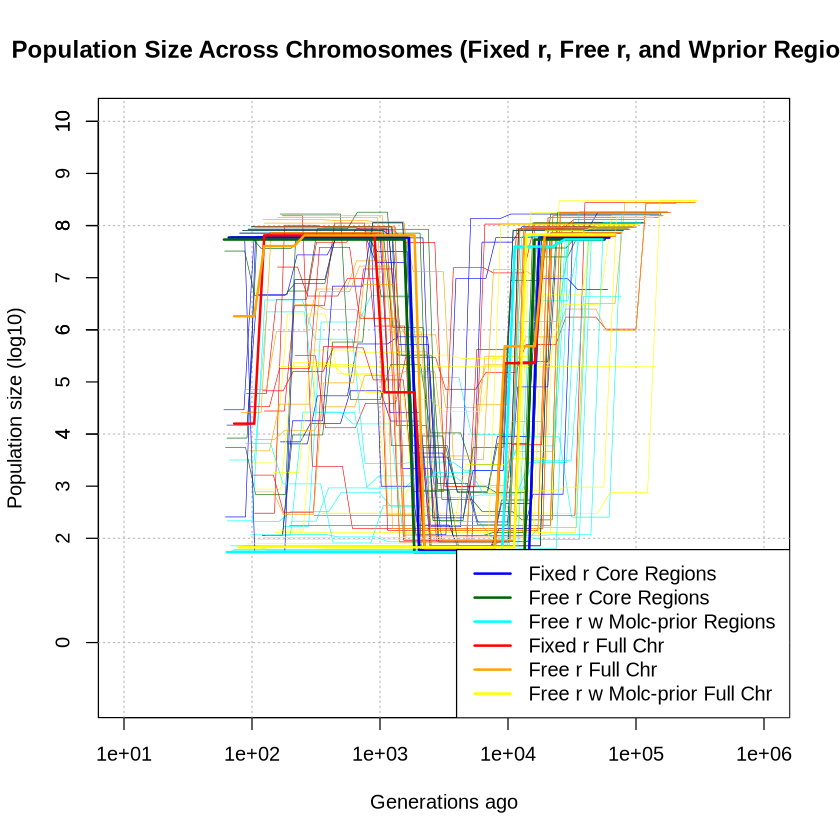

In [4]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16   # Generation time

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(-1, 10), 
     xlim = c(10, 10^6), 
     type = "n", 
     xlab = "Generations ago", 
     ylab = "Population size (log10)", 
     main = "Population Size Across Chromosomes (Fixed r, Free r, and Wprior Regions)")

# Define y-axis ticks (optional, if you need customization)
y_ticks <- seq(3, 10, by = 1)  # Steps of 1
axis(2, at = y_ticks, labels = y_ticks)  # Add custom y-axis ticks

# Add grid lines for better visualization
grid(nx = NULL, ny = NULL, col = "gray", lty = "dotted")

# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_smbc_regions_fixed_r)) {

  # Skip 14 as it will be plotted separately
  if (chr != "allchr") {

    # Fixed_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]$mu / mu)  # Fixed mu for Fixed_r
      lines(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "blue", lwd = 0.5)  # Blue for Fixed_r Regions
    }

    # Free_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]$mu / mu)  # Fixed mu for Free_r Regions
      lines(plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)  # Dark green for Free_r Regions
    }

    # Free_r with prior Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]$mu / mu)  # Fixed mu for Free_r with prior
      lines(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "cyan", lwd = 0.5)  # Cyan for Free_r with prior Regions
    }

    # Fixed_r Full Chr plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]$mu / mu)  # Fixed mu for Fixed_r Full Chr
      lines(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "red", lwd = 0.5)  # Red for Fixed_r Full Chr
    }

    # Free_r Full Chr plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]$mu / mu)  # Fixed mu for Free_r Full Chr
      lines(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "orange", lwd = 0.5)  # Orange for Free_r Full Chr
    }

    # Free_r with prior Full Chr plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) &&
        length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) > 0) {
      Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]$mu / mu)  # Fixed mu for Free_r with prior Full Chr
      lines(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "yellow", lwd = 0.5)  # Yellow for Free_r with prior Full Chr
    }
  }
}

# Plot "All Chromosome" lines in bold
# Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']]) &&
    length(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_regions_fixed_r[['13']][[1]]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']][[1]]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_regions_fixed_r[['13']][[1]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "blue", lwd = 2)
}

# Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r[['14']]) &&
    length(plot_data_list_newhetfile_smbc_regions_free_r[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r[['14']][[1]]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r[['14']][[1]]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_regions_free_r[['14']][[1]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# Free_r with prior Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']]) &&
    length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']][[1]]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']][[1]]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_regions_free_r_wprior[['14']][[1]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "cyan", lwd = 2)
}

# Fixed_r Full Chr "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]) &&
    length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_full_chr_fixed_r[['14']]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "red", lwd = 2)
}

# Free_r Full Chr "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]) &&
    length(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_full_chr_free_r[['14']]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "orange", lwd = 2)
}

# Free_r with prior Full Chr "All Chromosome"
if (!is.null(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]) &&
    length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]) > 0) {
  Ne_t <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]$Xi
  Ne <- mean(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]$mu / mu)
  lines(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[['14']]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "yellow", lwd = 2)
}

  

# Add a legend for the main lines
legend("bottomright", 
       legend = c("Fixed r Core Regions", "Free r Core Regions", "Free r w Molc-prior Regions", 
                  "Fixed r Full Chr", "Free r Full Chr", "Free r w Molc-prior Full Chr"),
       col = c("blue", "darkgreen", "cyan", "red", "orange", "yellow"), 
       lty = 1, lwd = 2)


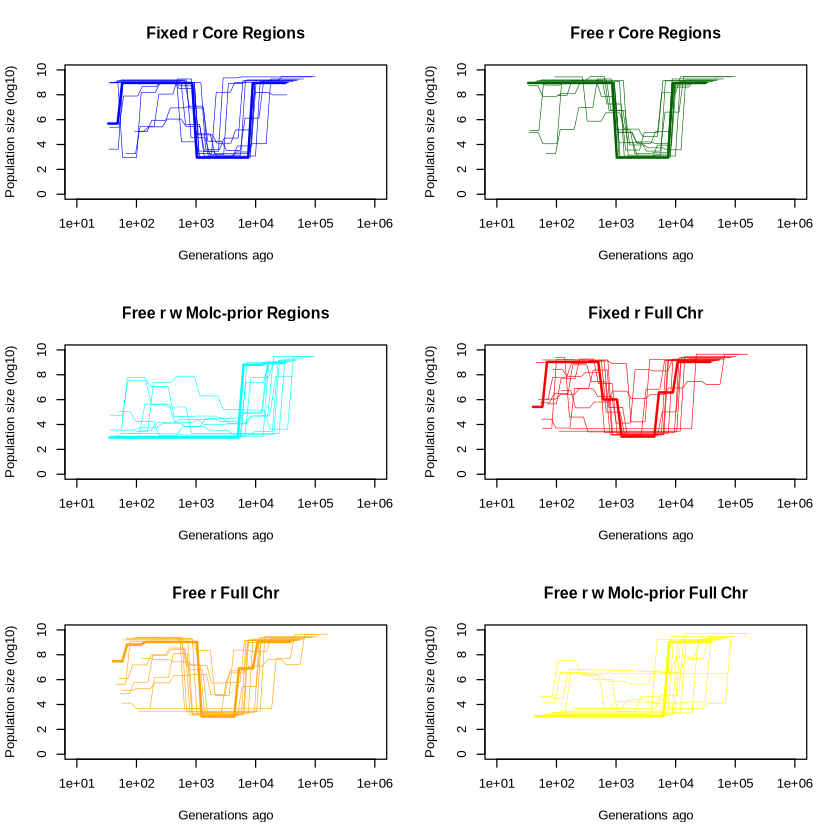

In [5]:
# Set mutation rate and generation time
mu <- 2.45e-10  # Default mutation rate
gen <- 0.0054   # Generation time

# Set plot layout: 3 rows, 2 columns
par(bg = "white", mfrow = c(3, 2))  

# Function to plot regions data
plot_regions <- function(title, data_list, col) {
  plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
       type = "n", xlab = "Generations ago", ylab = "Population size (log10)", main = title)
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- data_list[[chr]][[1]]$Xi
      Ne <- mean(data_list[[chr]][[1]]$mu / mu)
      lines(data_list[[chr]][[1]]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 0.5)
    }
  }
  
  if (!is.null(data_list[['14']]) && length(data_list[['14']]) > 0) {
    Ne_t <- data_list[['14']][[1]]$Xi
    Ne <- mean(data_list[['14']][[1]]$mu / mu)
    lines(data_list[['14']][[1]]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 2)
  }
}

# Function to plot full chromosome data
plot_full_chr <- function(title, data_list, col) {
  plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
       type = "n", xlab = "Generations ago", ylab = "Population size (log10)", main = title)
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- data_list[[chr]]$Xi
      Ne <- mean(data_list[[chr]]$mu / mu)
      lines(data_list[[chr]]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 0.5)
    }
  }
  
  if (!is.null(data_list[['14']]) && length(data_list[['14']]) > 0) {
    Ne_t <- data_list[['14']]$Xi
    Ne <- mean(data_list[['14']]$mu / mu)
    lines(data_list[['14']]$Tc * Ne * gen, log10(Ne_t * Ne), col = col, lwd = 2)
  }
}


# Plot each data set in separate panels
plot_regions("Fixed r Core Regions", plot_data_list_newhetfile_smbc_regions_fixed_r, "blue")
plot_regions("Free r Core Regions", plot_data_list_newhetfile_smbc_regions_free_r, "darkgreen")
plot_regions("Free r w Molc-prior Regions", plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan")
plot_full_chr("Fixed r Full Chr", plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red")
plot_full_chr("Free r Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r, "orange")
plot_full_chr("Free r w Molc-prior Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow")

# Reset layout
par(mfrow = c(1, 1))


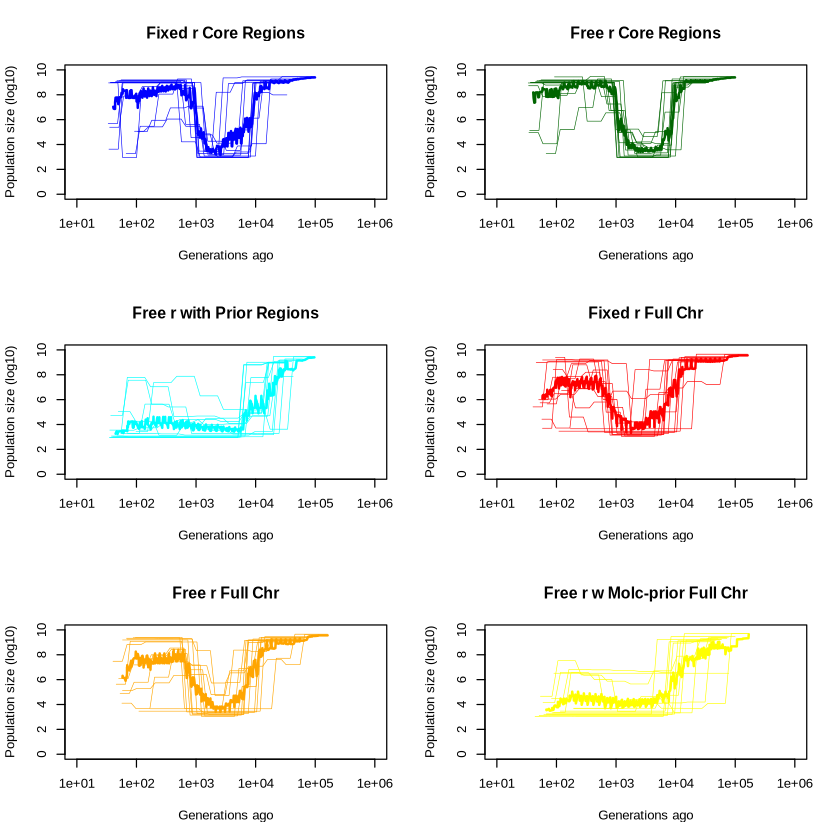

In [6]:

# Set plot layout: 3 rows, 2 columns
par(bg = "white", mfrow = c(3, 2))  

# Function to calculate and plot rolling average
plot_with_rolling_avg <- function(title, data_list, col, is_region = TRUE) {
  plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
       type = "n", xlab = "Generations ago", ylab = "Population size (log10)", main = title)
  
  all_lines <- list()
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- if (is_region) data_list[[chr]][[1]]$Xi else data_list[[chr]]$Xi
      Ne <- mean(if (is_region) data_list[[chr]][[1]]$mu else data_list[[chr]]$mu) / mu
      Tc <- if (is_region) data_list[[chr]][[1]]$Tc else data_list[[chr]]$Tc
      generations <- Tc * Ne * gen
      population <- log10(Ne_t * Ne)
      
      # Store lines data for rolling average calculation
      all_lines <- append(all_lines, list(data.frame(generations, population)))
      
      lines(generations, population, col = col, lwd = 0.5)
    }
  }
  
  # Calculate rolling average if there are any lines
  if (length(all_lines) > 0) {
    combined_data <- do.call(rbind, all_lines)
    combined_data <- combined_data[order(combined_data$generations), ]
    combined_data <- combined_data[!duplicated(combined_data$generations), ]  # Remove duplicate x-values
    
    roll_pop <- rollapply(combined_data$population, width = 10, FUN = mean, fill = NA, align = "right")
    valid_indices <- !is.na(roll_pop)  # Ensure lengths match
    roll_gen <- combined_data$generations[valid_indices]
    roll_pop <- roll_pop[valid_indices]
    
    lines(roll_gen, roll_pop, col = col, lwd = 2)
  }
}

# Plot each data set with rolling average
plot_with_rolling_avg("Fixed r Core Regions", plot_data_list_newhetfile_smbc_regions_fixed_r, "blue", is_region = TRUE)
plot_with_rolling_avg("Free r Core Regions", plot_data_list_newhetfile_smbc_regions_free_r, "darkgreen", is_region = TRUE)
plot_with_rolling_avg("Free r with Prior Regions", plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan", is_region = TRUE)
plot_with_rolling_avg("Fixed r Full Chr", plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red", is_region = FALSE)
plot_with_rolling_avg("Free r Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r, "orange", is_region = FALSE)
plot_with_rolling_avg("Free r w Molc-prior Full Chr", plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow", is_region = FALSE)

# Reset layout
par(mfrow = c(1, 1))


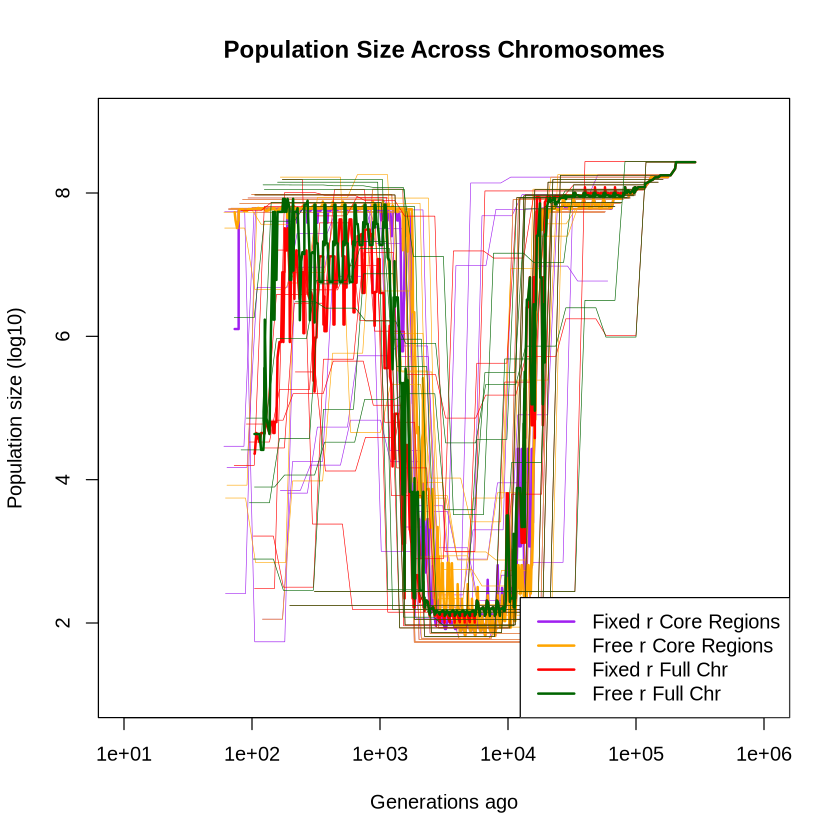

In [8]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16   # Generation time

# Set up single plot area with logarithmic x-axis
par(bg = "white")
plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(1, 9), xlim = c(10, 10^6), 
     type = "n", xlab = "Generations ago", ylab = "Population size (log10)", 
     main = "Population Size Across Chromosomes")

# Function to plot with rolling average
plot_with_rolling_avg <- function(data_list, col, is_region = TRUE) {
  all_lines <- list()
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- if (is_region) data_list[[chr]][[1]]$Xi else data_list[[chr]]$Xi
      Ne <- mean(if (is_region) data_list[[chr]][[1]]$mu else data_list[[chr]]$mu) / mu
      Tc <- if (is_region) data_list[[chr]][[1]]$Tc else data_list[[chr]]$Tc
      generations <- Tc * Ne * gen
      population <- log10(Ne_t * Ne)
      
      # Store for rolling average
      all_lines <- append(all_lines, list(data.frame(generations, population)))
      
      lines(generations, population, col = col, lwd = 0.5)
    }
  }
  
  # Rolling average
  if (length(all_lines) > 0) {
    combined_data <- do.call(rbind, all_lines)
    combined_data <- combined_data[order(combined_data$generations), ]
    combined_data <- combined_data[!duplicated(combined_data$generations), ]
    
    roll_pop <- rollapply(combined_data$population, width = 10, FUN = median, fill = NA, align = "right")
    valid_indices <- !is.na(roll_pop)
    roll_gen <- combined_data$generations[valid_indices]
    roll_pop <- roll_pop[valid_indices]
    
    lines(roll_gen, roll_pop, col = col, lwd = 2)
  }
}

# Plot each data set on the same plot
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_regions_fixed_r, "purple", is_region = TRUE)
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_regions_free_r, "orange", is_region = TRUE)
#plot_with_rolling_avg(plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan", is_region = TRUE)
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red", is_region = FALSE)
plot_with_rolling_avg(plot_data_list_newhetfile_smbc_full_chr_free_r, "darkgreen", is_region = FALSE)
#plot_with_rolling_avg(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow", is_region = FALSE)

# Add a legend for the main lines
legend("bottomright", 
       legend = c("Fixed r Core Regions", "Free r Core Regions", #"Free r w Molc-prior Regions", 
                  "Fixed r Full Chr", "Free r Full Chr"),#, "Free r w Molc-prior Full Chr"),
       col = c("purple", "orange", "red", "darkgreen"), 
       lty = 1, lwd = 2)


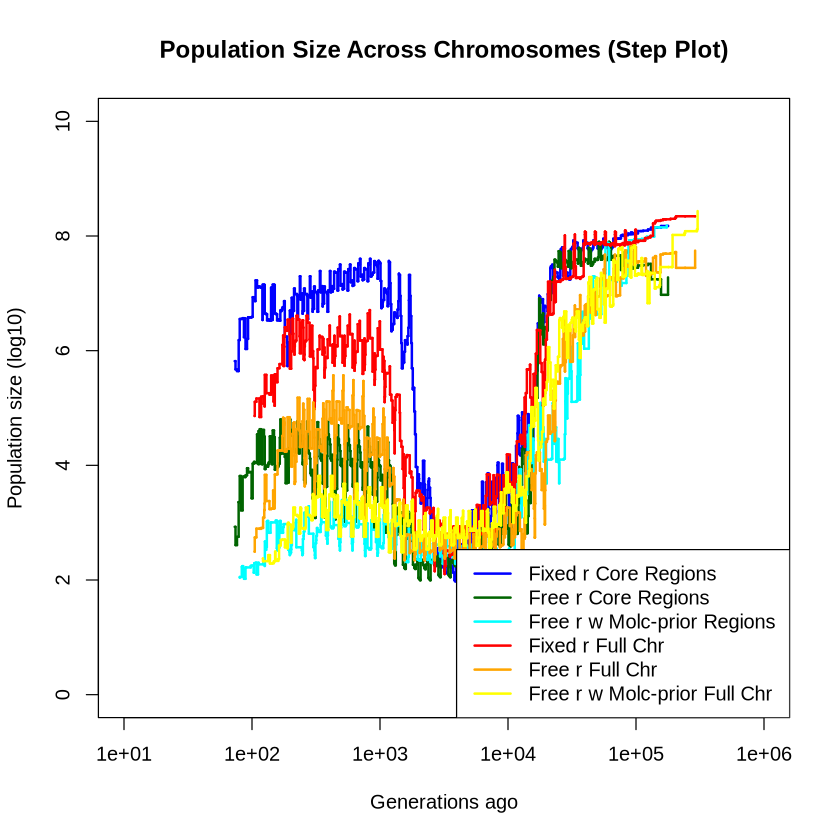

In [8]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16   # Generation time

# Set up a single plot with logarithmic x-axis
par(bg = "white")
plot(c(1000, 5 * 10^7), c(1, 1), log = "x", ylim = c(0, 10), xlim = c(10, 10^6), 
     type = "n", xlab = "Generations ago", ylab = "Population size (log10)", 
     main = "Population Size Across Chromosomes (Step Plot)")

# Function to plot using step-like lines (no points)
plot_with_step_and_avg <- function(data_list, col, is_region = TRUE) {
  all_lines <- list()
  
  for (chr in names(data_list)) {
    if (!is.null(data_list[[chr]]) && length(data_list[[chr]]) > 0) {
      Ne_t <- if (is_region) data_list[[chr]][[1]]$Xi else data_list[[chr]]$Xi
      Ne <- mean(if (is_region) data_list[[chr]][[1]]$mu else data_list[[chr]]$mu) / mu
      Tc <- if (is_region) data_list[[chr]][[1]]$Tc else data_list[[chr]]$Tc
      generations <- Tc * Ne * gen
      population <- log10(Ne_t * Ne)
      
      # Store for rolling average calculation
      all_lines <- append(all_lines, list(data.frame(generations, population)))
    
    }
  }
  
  # Rolling average
  if (length(all_lines) > 0) {
    combined_data <- do.call(rbind, all_lines)
    combined_data <- combined_data[order(combined_data$generations), ]
    combined_data <- combined_data[!duplicated(combined_data$generations), ]
    
    roll_pop <- rollapply(combined_data$population, width = 10, FUN = mean, fill = NA, align = "right")
    valid_indices <- !is.na(roll_pop)
    roll_gen <- combined_data$generations[valid_indices]
    roll_pop <- roll_pop[valid_indices]
    
    # Plot rolling average as step-like lines
    for (i in 1:(length(roll_gen) - 1)) {
      segments(x0 = roll_gen[i], y0 = roll_pop[i], x1 = roll_gen[i + 1], y1 = roll_pop[i], col = col, lwd = 2)
      segments(x0 = roll_gen[i + 1], y0 = roll_pop[i], x1 = roll_gen[i + 1], y1 = roll_pop[i + 1], col = col, lwd = 2)
    }
  }
}

# Plot each dataset using step-like lines
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_regions_fixed_r, "blue", is_region = TRUE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_regions_free_r, "darkgreen", is_region = TRUE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_regions_free_r_wprior, "cyan", is_region = TRUE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_full_chr_fixed_r, "red", is_region = FALSE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_full_chr_free_r, "orange", is_region = FALSE)
plot_with_step_and_avg(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior, "yellow", is_region = FALSE)

# Add a legend for the main lines
legend("bottomright", 
       legend = c("Fixed r Core Regions", "Free r Core Regions", "Free r w Molc-prior Regions", 
                  "Fixed r Full Chr", "Free r Full Chr", "Free r w Molc-prior Full Chr"),
       col = c("blue", "darkgreen", "cyan", "red", "orange", "yellow"), 
       lty = 1, lwd = 2)




In [ ]:
chr_data$

[1] "01" "02" "03" "04" "05" "06" "07" "08" "09" "10" "11" "12" "13" "14"

In [87]:
names(plot_data_list_newhetfile_smbc_regions)[9:14]

[1] "09" "10" "11" "12" "13" "14"

In [4]:
# Initialize empty vectors for alpha and rho/mu values
rho_values <- c()
alpha_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()  # To store valid chromosome names
category_labels <- c()  # To store categories (e.g., Free_r Regions, Free_r Full)

for (chr in names(plot_data_list_newhetfile_smbc_regions_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            # Append data to the vectors

            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)  # Add chromosome name
            category_labels <- c(category_labels, rep("Fixed r Core Regions", length(chr_data$rho)))
        }
    }
}

# Loop through Free_r Full data
for (chr in c(names(plot_data_list_newhetfile_smbc_regions_free_r))) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r Core Regions", length(chr_data$rho)))
        }
    }
}

# Loop through Free_r Full data
for (chr in c(names(plot_data_list_newhetfile_smbc_regions_free_r_wprior))) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r w Molc-prior Regions", length(chr_data$rho)))
        }
    }
}

#category_labels <- c(category_labels, rep("Free r Regions", 14))

# Loop through Fixed_r data
for (chr in c(names(plot_data_list_newhetfile_smbc_full_chr_fixed_r))) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Fixed r Full Chr", length(chr_data$rho)))
        }
    }
}
#category_labels <- c(category_labels, rep("Fixed r Full Chr", 13))

# Loop through Fixed_r Free data
for (chr in c(names(plot_data_list_newhetfile_smbc_full_chr_free_r))) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r Full Chr", length(chr_data$rho)))
        }
    }
}
for (chr in c(names(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior))) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) > 0) {  # Ensure the object is not empty
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]
        if (!is.null(chr_data$rho) && !is.null(chr_data$alpha) && 
            length(chr_data$rho) > 0 && length(chr_data$alpha) > 0) {
            rho_values <- c(rho_values, chr_data$rho)
            alpha_values <- c(alpha_values, chr_data$alpha)
            rho_mu_ratios <- c(rho_mu_ratios, chr_data$rho / chr_data$mu)
            chromosomes <- c(chromosomes, chr)
            category_labels <- c(category_labels, rep("Free r w Molc-prior Full Chr", length(chr_data$rho)))
        }
    }
}
#category_labels <- c(category_labels, rep("Free r Full Chr", 13))

# Create a data frame for plotting
boxplot_data <- data.frame(
    Rho = rho_values,
    Alpha = alpha_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = category_labels
)

boxplot_data


Rho,Alpha,Rho_Mu_Ratio,Category
<dbl>,<dbl>,<dbl>,<chr>
0.006733061,1.35,10.000000,Fixed r Core Regions
0.003841292,1.25,10.000000,Fixed r Core Regions
0.002897109,1.10,10.000000,Fixed r Core Regions
0.007309511,1.25,10.000000,Fixed r Core Regions
0.002523390,1.30,10.000000,Fixed r Core Regions
0.002456498,1.30,10.000000,Fixed r Core Regions
0.004572520,1.20,10.000000,Fixed r Core Regions
0.003446240,1.15,10.000000,Fixed r Core Regions
0.002429454,1.15,10.000000,Fixed r Core Regions


In [5]:


boxplot_data<-boxplot_data %>% 
    filter(!grepl("Molc-prior", Category))
boxplot_data

Rho,Alpha,Rho_Mu_Ratio,Category
<dbl>,<dbl>,<dbl>,<chr>
0.006733061,1.35,10.000000,Fixed r Core Regions
0.003841292,1.25,10.000000,Fixed r Core Regions
0.002897109,1.10,10.000000,Fixed r Core Regions
0.007309511,1.25,10.000000,Fixed r Core Regions
0.002523390,1.30,10.000000,Fixed r Core Regions
0.002456498,1.30,10.000000,Fixed r Core Regions
0.004572520,1.20,10.000000,Fixed r Core Regions
0.003446240,1.15,10.000000,Fixed r Core Regions
0.002429454,1.15,10.000000,Fixed r Core Regions


In [15]:
boxplot_data$Category <- factor(boxplot_data$Category)


print(levels(boxplot_data$Category))


[1] "Fixed r Core Regions" "Fixed r Full Chr"     "Free r Core Regions" 
[4] "Free r Full Chr"     


In [16]:
library(dplyr)

# Calculate medians for Alpha by Category
medians_alpha <- boxplot_data %>%
  group_by(Category) %>%
  summarise(Median_Alpha = median(Alpha, na.rm = TRUE))

# Print the table of medians
print(medians_alpha)


# A tibble: 4 × 2
  Category             Median_Alpha
  <fct>                       <dbl>
1 Fixed r Core Regions         1.18
2 Fixed r Full Chr             1.1 
3 Free r Core Regions          1.18
4 Free r Full Chr              1.1 


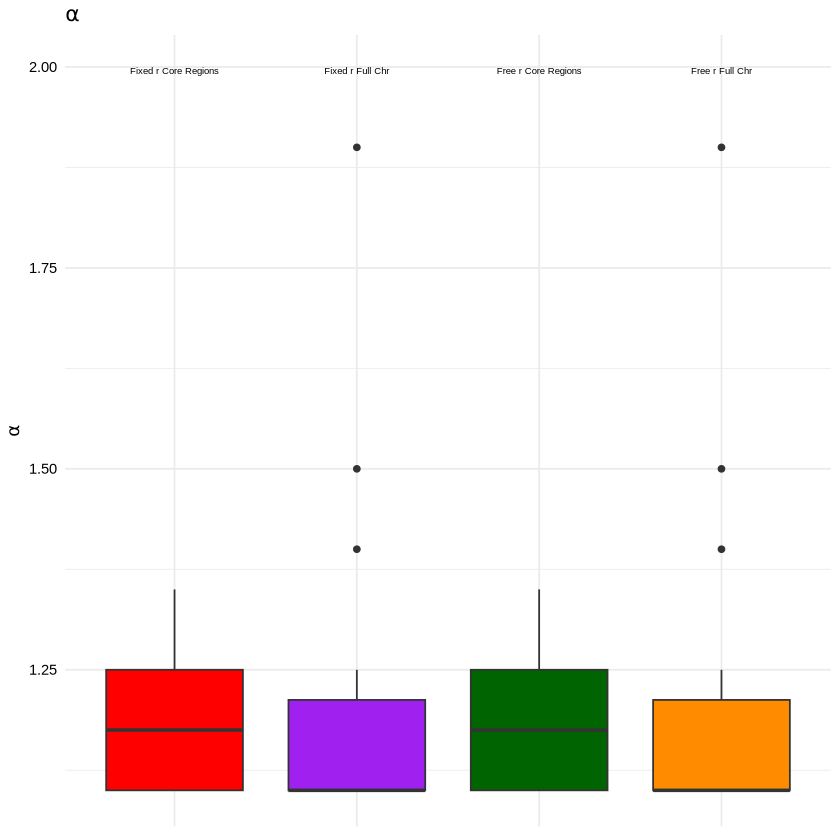

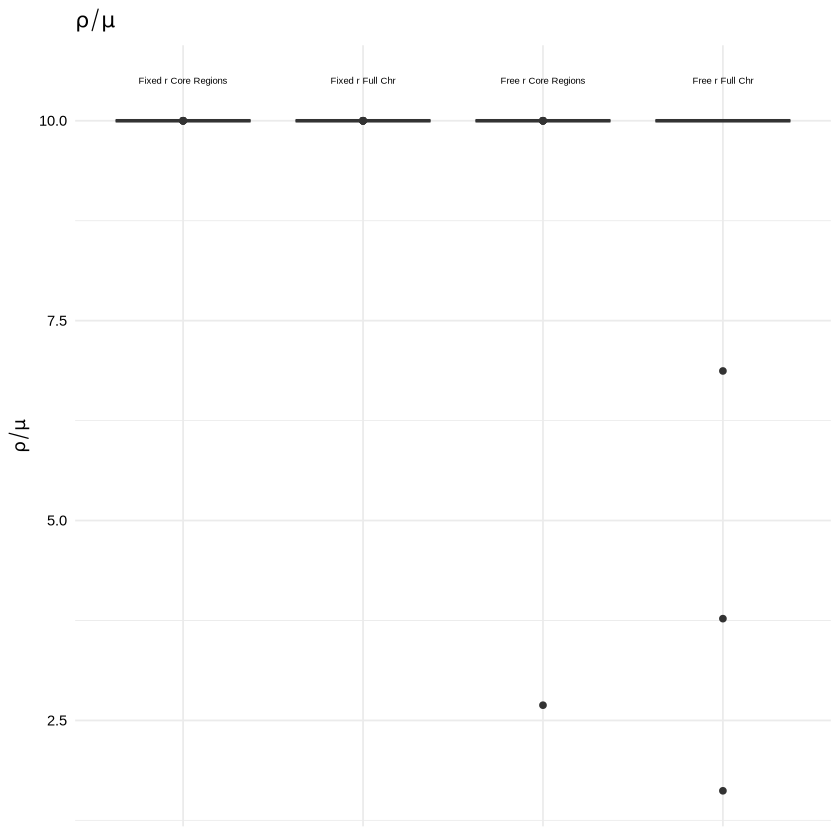

In [17]:
# Boxplot for Alpha
plot_alpha <- ggplot(boxplot_data, aes(x = Category, y = Alpha, fill = Category)) +
    geom_boxplot() +
    labs(title = expression(alpha), y = expression(alpha)) +
    scale_fill_manual(values = c("red", "purple", "darkgreen", "darkorange","blue","yellow"), name = "Category") +
    theme_minimal() +
    theme(
        legend.position = "none", # Remove legend
        axis.text.x = element_blank(), # Remove x-axis text
        axis.title.x = element_blank(),
        axis.text = element_text(color = "black"),
        axis.title = element_text(color = "black"),
        plot.title = element_text(color = "black")
    ) +
    annotate("text", x = 1:4, y = max(boxplot_data$Alpha, na.rm = TRUE) * 1.05, # Position above boxplots
             label = levels(boxplot_data$Category), size = 2, color = "black") # Add labels

plot_alpha

# Boxplot for Rho/Mu
plot_rho_mu <- ggplot(boxplot_data, aes(x = Category, y = Rho_Mu_Ratio, fill = Category)) +
    geom_boxplot() +
    labs(title = expression(rho / mu), y = expression(rho / mu)) +
    scale_fill_manual(values = c("red", "purple", "darkgreen", "darkorange","blue","yellow"), name = "Category") +
    theme_minimal() +
     theme(
        legend.position = "none", # Remove legend
        axis.text.x = element_blank(), # Remove x-axis text
        axis.title.x = element_blank(),
        axis.text = element_text(color = "black"),
        axis.title = element_text(color = "black"),
        plot.title = element_text(color = "black")
    ) +
    annotate("text", x = 1:4, y = max(boxplot_data$Rho_Mu_Ratio, na.rm = TRUE) * 1.05, # Position above boxplots
             label = levels(boxplot_data$Category), size = 2, color = "black") # Add labels

plot_rho_mu


In [19]:
names(plot_data_list_newhetfile_smbc_full_chr_free_r)

[1] "01" "02" "03" "04" "05" "06" "07" "08" "09" "10" "11" "12" "13" "14"

In [18]:
tail(names(plot_data_list_newhetfile_smbc_full_chr), 5)

ERROR: Error: object 'plot_data_list_newhetfile_smbc_full_chr' not found


In [6]:
# Initialize an empty list to collect data for all datasets
dot_plot_data <- data.frame()

# Loop through the last 5 chromosomes for each plot dataset

# 1. Fixed r Regions
for (chr in names(plot_data_list_newhetfile_smbc_regions_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_regions_fixed_r[[chr]][[1]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Fixed r Core Regions"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

# 2. Free r Regions
for (chr in names(plot_data_list_newhetfile_smbc_regions_free_r)) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r[[chr]][[1]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r Core Regions"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

for (chr in names(plot_data_list_newhetfile_smbc_regions_free_r_wprior)) {
    if (length(plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_regions_free_r_wprior[[chr]][[1]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r w Molc-prior Core Regions"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

# 3. Fixed r Full Chr
for (chr in names(plot_data_list_newhetfile_smbc_full_chr_fixed_r)) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_fixed_r[[chr]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Fixed r Full Chr"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

# 4. Free r Full Chr
for (chr in names(plot_data_list_newhetfile_smbc_full_chr_free_r)) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r[[chr]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r Full Chr"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

for (chr in names(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior)) {
    if (length(plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]) > 0) {
        chr_data <- plot_data_list_newhetfile_smbc_full_chr_free_r_wprior[[chr]]
        if (!is.null(chr_data$alpha) && length(chr_data$alpha) > 0) {
            temp_data <- data.frame(
                Chromosome = chr,
                Alpha = chr_data$alpha,
                Dataset = "Free r w Molc-prior Full Chr"
            )
            dot_plot_data <- rbind(dot_plot_data, temp_data)
        }
    }
}

dot_plot_data

Chromosome,Alpha,Dataset
<chr>,<dbl>,<chr>
01,1.35,Fixed r Core Regions
02,1.25,Fixed r Core Regions
03,1.10,Fixed r Core Regions
04,1.25,Fixed r Core Regions
05,1.30,Fixed r Core Regions
06,1.30,Fixed r Core Regions
07,1.20,Fixed r Core Regions
08,1.15,Fixed r Core Regions
09,1.15,Fixed r Core Regions


In [8]:
# Assuming your data is in a data frame called df
free_core <- subset(dot_plot_data, Dataset == "Free r Core Regions")

# Save to CSV
write.table(free_core, "Free_r_Core_Regions_ncv.csv", row.names = FALSE, sep = "\t", quote = FALSE)


In [21]:
# Define custom colors for each Dataset
custom_colors <- c(
"Fixed r Full Chr" = "coral",      # Coral (red)
    "Free r Full Chr" = "coral",       # Coral (orange)
    "Free r w Molc-prior Full Chr" = "coral", # Blue
    "Fixed r Core Regions" = "palegreen3",  # Light green
    "Free r Core Regions" = "palegreen3",   # Light green
    "Free r w Molc-prior Core Regions" = "palegreen3"  # Blue
)
# Create a coded version for x-axis (coded labels)
#coded_labels <- c("FRC", "FRCwP", "FFC", "FFCR", "FRRwP", "FRR")

# Create a simplified version for the x-axis (coded labels)
#dot_plot_data$SimplifiedDataset <- factor(dot_plot_data$Dataset, 
#                                          levels = names(custom_colors),
#                                          labels = coded_labels)
#
# Ensure that the 'Dataset' column is a factor with correct levels corresponding to custom colors
dot_plot_data$Dataset <- factor(dot_plot_data$Dataset, levels = names(custom_colors))

# Filter data to only include chromosomes 09 to 14
chromosomes_09_to_14 <- c("09", "10", "11", "12", "13", "14")
filtered_data <- dot_plot_data[dot_plot_data$Chromosome %in% chromosomes_09_to_14, ]
dot_plot_data

Chromosome,Alpha,Dataset
<chr>,<dbl>,<fct>
01,1.35,Fixed r Core Regions
02,1.25,Fixed r Core Regions
03,1.10,Fixed r Core Regions
04,1.25,Fixed r Core Regions
05,1.30,Fixed r Core Regions
06,1.30,Fixed r Core Regions
07,1.20,Fixed r Core Regions
08,1.15,Fixed r Core Regions
09,1.15,Fixed r Core Regions


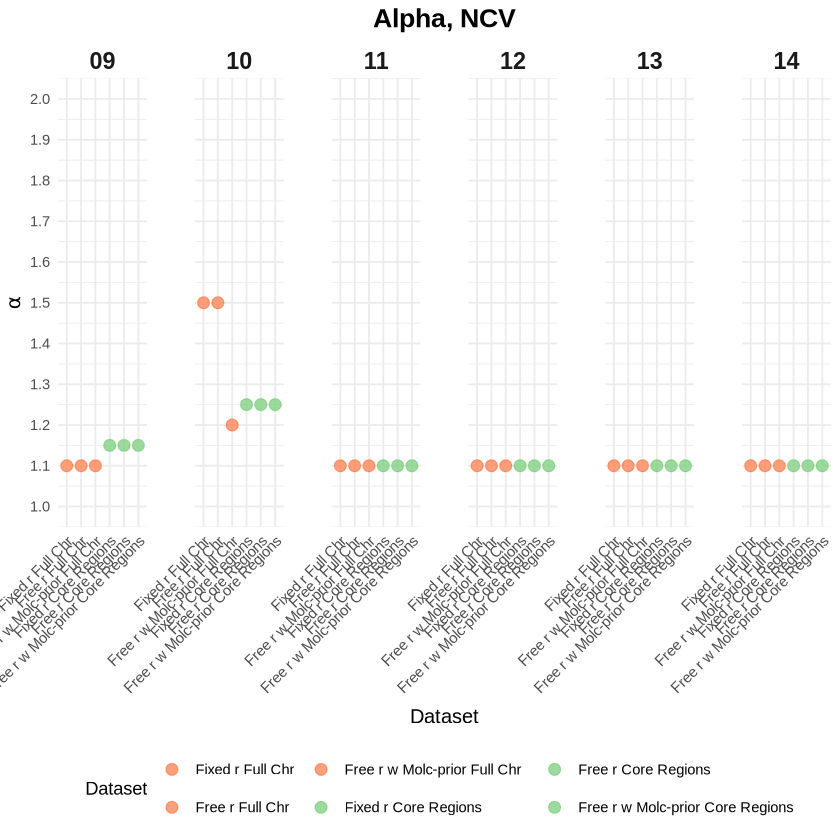

In [22]:

# Create the dot plot
dot_plot <- ggplot(filtered_data, aes(x = Dataset, y = Alpha, color = Dataset)) +
    geom_point(size = 3, alpha = 0.75) +  
    labs(
        title = "Alpha, NCV",
        x = "Dataset",
        y = expression(alpha)
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 14, face = "bold"),
        legend.position = "bottom",
        panel.spacing = unit(2, "lines")
    ) +
    facet_wrap(~Chromosome, ncol = 6) +  
    scale_y_continuous(limits = c(1, 2), breaks = seq(1, 2, by = 0.1)) +
    scale_color_manual(values = custom_colors)

# Display the plot
print(dot_plot)




In [23]:
# Reshape the data into long format if needed
heatmap_data <- melt(dot_plot_data, id.vars = c("Dataset", "Chromosome"))
names(heatmap_data)<-c("Dataset","Chromosome","variable","Alpha")
heatmap_data

Dataset,Chromosome,variable,Alpha
<fct>,<chr>,<fct>,<dbl>
Fixed r Core Regions,01,Alpha,1.35
Fixed r Core Regions,02,Alpha,1.25
Fixed r Core Regions,03,Alpha,1.10
Fixed r Core Regions,04,Alpha,1.25
Fixed r Core Regions,05,Alpha,1.30
Fixed r Core Regions,06,Alpha,1.30
Fixed r Core Regions,07,Alpha,1.20
Fixed r Core Regions,08,Alpha,1.15
Fixed r Core Regions,09,Alpha,1.15


In [24]:

heatmap_data <- heatmap_data %>% 
    filter(variable == "Alpha" & !grepl("Free r w Molc-prior", Dataset))

# Display the filtered data
heatmap_data[,"Alpha"]<-as.numeric(heatmap_data[,"Alpha"])


heatmap_data


Dataset,Chromosome,variable,Alpha
<fct>,<chr>,<fct>,<dbl>
Fixed r Core Regions,01,Alpha,1.35
Fixed r Core Regions,02,Alpha,1.25
Fixed r Core Regions,03,Alpha,1.10
Fixed r Core Regions,04,Alpha,1.25
Fixed r Core Regions,05,Alpha,1.30
Fixed r Core Regions,06,Alpha,1.30
Fixed r Core Regions,07,Alpha,1.20
Fixed r Core Regions,08,Alpha,1.15
Fixed r Core Regions,09,Alpha,1.15


In [25]:
#install.packages("RColorBrewer")  # Install the package if you haven't
 # Load the package
library(RColorBrewer)

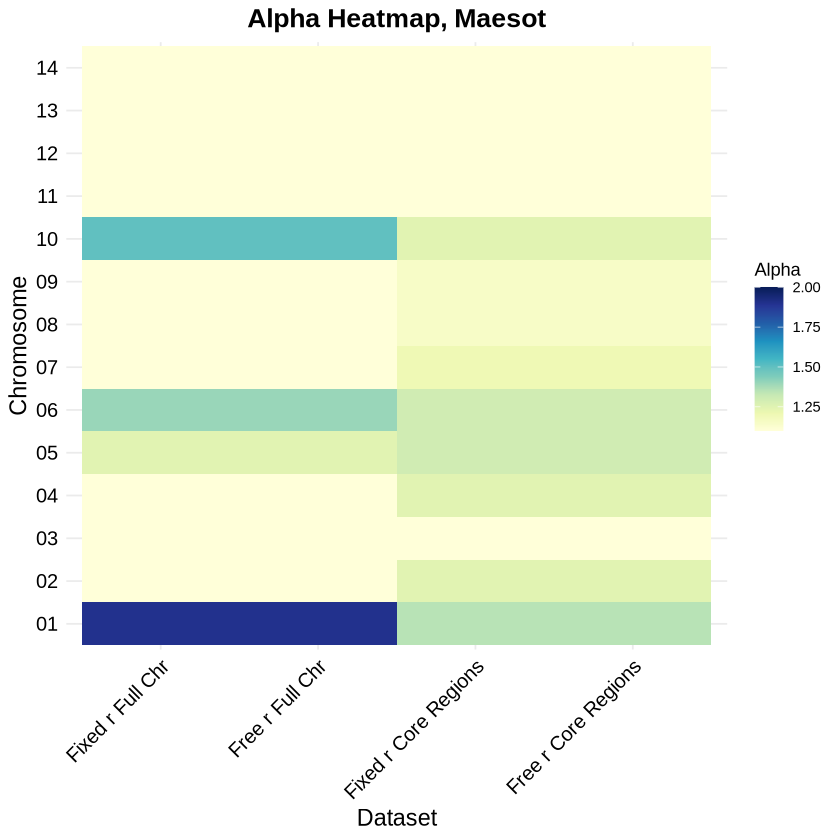

In [26]:

# Heatmap visualization
heatmap_plot <- ggplot(heatmap_data, aes(x = Dataset, y = Chromosome, fill = Alpha)) +
    geom_tile() +
    scale_fill_gradientn(
        colors = brewer.pal(9, "YlGnBu"),  # Color palette
        limits = c(1.1, 2)  # Setting the range for the gradient
    ) +
    labs(title = "Alpha Heatmap, Maesot", x = "Dataset", y = "Chromosome") +
    theme_minimal() +
    theme(
        plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 14),
        axis.title.y = element_text(size = 14),
        axis.text.x = element_text(size = 12, angle = 45, hjust = 1, color = "black"),
        axis.text.y = element_text(size = 12, color = "black"),  # Make y-axis tick labels black
        strip.text = element_text(size = 16, face = "bold", color = "black")
    )

# Display the heatmap
print(heatmap_plot)



In [27]:
# Read the data (replace 'your_file.txt' with the actual file name)
data <- read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Div_Recomb_stats/BinhPhuoc_sfs_full.txt", header = T ,sep="\t")
#data
# Extract rows 5 to 15 (adjust column indices as necessary)
subset_data <- data[,-c(1:2)]  # Exclude the first column if it's not part of the SFS

subset_data

X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,⋯,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.1923621,0.1145686,0.08345120,0.05940594,0.04667610,0.03111740,0.04526167,0.02121641,0.01697313,0.01131542,⋯,0.0014144272,0.0028288543,0.0000000000,0.0000000000,0.001414427,0.0000000000,0.0000000000,0.0000000000,0.0028288543,0
0.2377131,0.1233701,0.09327984,0.06018054,0.05215647,0.03610832,0.02507523,0.03009027,0.02407222,0.01805416,⋯,0.0010030090,0.0010030090,0.0020060181,0.0030090271,0.003009027,0.0010030090,0.0050150451,0.0010030090,0.0010030090,0
0.2537445,0.1550661,0.11277533,0.06343612,0.04669604,0.04140969,0.04140969,0.03171806,0.02290749,0.00969163,⋯,0.0008810573,0.0008810573,0.0008810573,0.0017621145,0.001762115,0.0035242291,0.0044052863,0.0017621145,0.0035242291,0
0.1882966,0.1112399,0.07647740,0.05156431,0.03418308,0.03418308,0.02665122,0.02549247,0.02491309,0.02201622,⋯,0.0011587486,0.0005793743,0.0017381228,0.0011587486,0.001738123,0.0011587486,0.0046349942,0.0017381228,0.0005793743,0
0.2772843,0.1516497,0.09835025,0.05710660,0.04505076,0.03870558,0.03616751,0.02157360,0.01649746,0.01395939,⋯,0.0019035533,0.0006345178,0.0019035533,0.0006345178,0.001903553,0.0025380711,0.0031725888,0.0031725888,0.0044416244,0
0.2572347,0.1430868,0.07556270,0.05466238,0.03295820,0.03135048,0.03215434,0.02250804,0.02331190,0.01527331,⋯,0.0016077170,0.0016077170,0.0016077170,0.0040192926,0.002411576,0.0032154341,0.0008038585,0.0048231511,0.0008038585,0
0.1939704,0.1234357,0.07337884,0.07337884,0.04778157,0.03356086,0.02957907,0.02616610,0.02275313,0.01934016,⋯,0.0022753129,0.0017064846,0.0028441411,0.0005688282,0.001706485,0.0022753129,0.0000000000,0.0039817975,0.0022753129,0
0.2150063,0.1462799,0.07187894,0.07124842,0.05359395,0.03404792,0.03089533,0.02837327,0.01954603,0.01324086,⋯,0.0006305170,0.0012610340,0.0006305170,0.0012610340,0.001891551,0.0000000000,0.0018915511,0.0025220681,0.0031525851,0
0.2515763,0.1450189,0.09079445,0.05800757,0.05422446,0.04918033,0.03404792,0.01828499,0.01765448,0.01513241,⋯,0.0006305170,0.0006305170,0.0000000000,0.0006305170,0.000630517,0.0025220681,0.0012610340,0.0018915511,0.0025220681,0


In [28]:
emp_sfs <- as.matrix(subset_data)

# Define cutoff value
cutoff <- 23# Adjust this as needed
n=156

rows_sums <- rowSums(emp_sfs[, cutoff:n])

results <- cbind(sprintf("%02d", 1:14),as.numeric(emp_sfs[,1]), as.numeric(rows_sums))
colnames(results)<-c("Chromosome","singleton","lumped_tail")
#Convert results to a data frame
results_df <- as.data.frame(results)

# Ensure that columns 2 and 3 are numeric
results_df$singleton <- as.numeric(results_df$singleton)
results_df$lumped_tail <- as.numeric(results_df$lumped_tail)

# Check the structure of the data frame to verify column types
results_df<-results_df[4:14,]


In [29]:
# Join df1 and df2 by Chromosome
merged_df <- left_join(heatmap_data, results_df, by = "Chromosome")
merged_df<-na.omit(merged_df)
merged_df

,Dataset,Chromosome,variable,Alpha,singleton,lumped_tail
,<fct>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
4,Fixed r Core Regions,04,Alpha,1.25,0.1882966,0.2601390
5,Fixed r Core Regions,05,Alpha,1.30,0.2772843,0.1414975
6,Fixed r Core Regions,06,Alpha,1.30,0.2572347,0.1985531
7,Fixed r Core Regions,07,Alpha,1.20,0.1939704,0.2417520
8,Fixed r Core Regions,08,Alpha,1.15,0.2150063,0.2206810
9,Fixed r Core Regions,09,Alpha,1.15,0.2515763,0.1569987
10,Fixed r Core Regions,10,Alpha,1.25,0.2479210,0.1632017
11,Fixed r Core Regions,11,Alpha,1.10,0.2562098,0.1324747
12,Fixed r Core Regions,12,Alpha,1.10,0.2683566,0.1210664


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


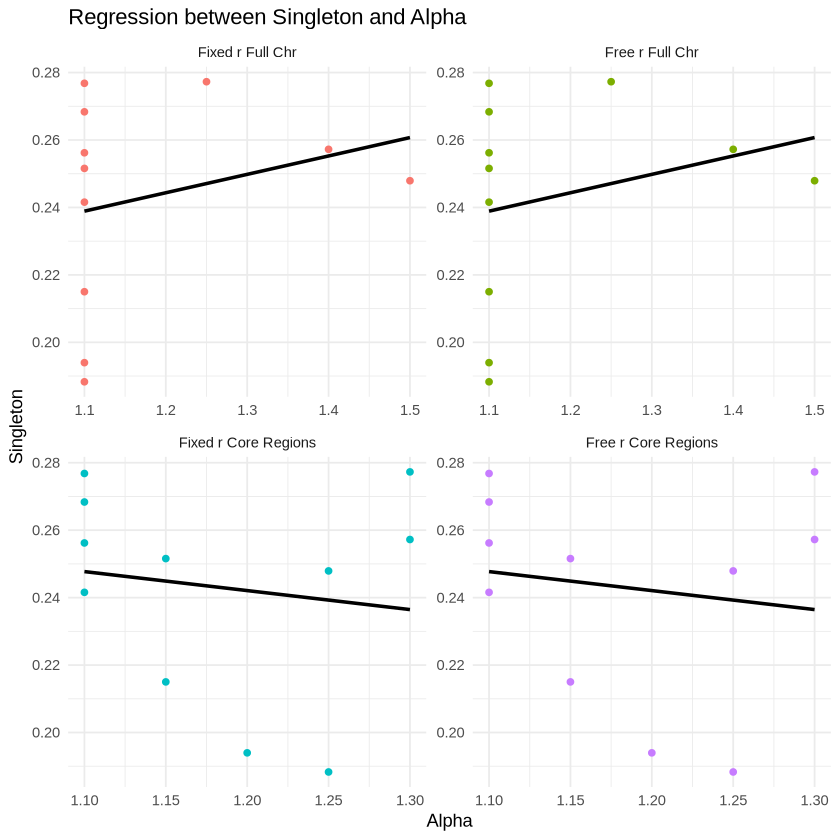

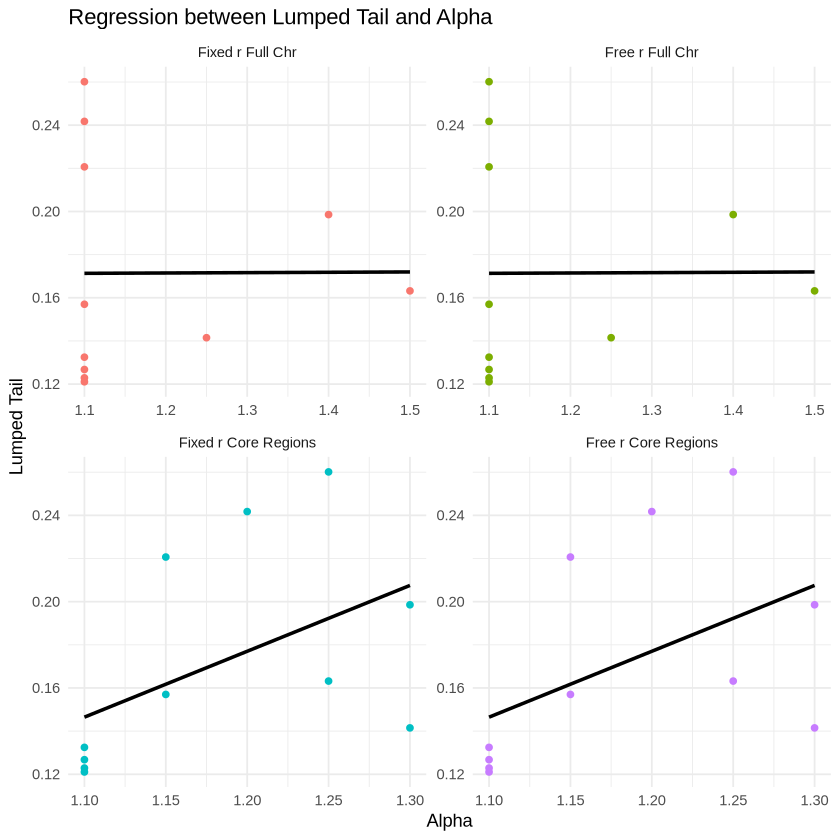

In [30]:
# Fit regression models for each category
# Plot for Singleton vs Alpha for each Dataset
plot_singleton_alpha <- ggplot(merged_df, aes(x = Alpha, y = singleton, color = Dataset)) +
  geom_point() +  # Plot points
  geom_smooth(method = "lm", se = FALSE, aes(group = Dataset), color = "black") +  # Add regression line
  labs(title = "Regression between Singleton and Alpha", 
       x = "Alpha", 
       y = "Singleton") +
  theme_minimal() +
  theme(legend.position = "none") +  # Hide legend for clarity in each plot
  facet_wrap(~Dataset, scales = "free")  # Facet by Dataset

# Plot for Lumped Tail vs Alpha for each Dataset
plot_lumped_tail_alpha <- ggplot(merged_df, aes(x = Alpha, y = lumped_tail, color = Dataset)) +
  geom_point() +  # Plot points
  geom_smooth(method = "lm", se = FALSE, aes(group = Dataset), color = "black") +  # Add regression line
  labs(title = "Regression between Lumped Tail and Alpha", 
       x = "Alpha", 
       y = "Lumped Tail") +
  theme_minimal() +
  theme(legend.position = "none") +  # Hide legend for clarity in each plot
  facet_wrap(~Dataset, scales = "free")  # Facet by Dataset

# Print both plots
print(plot_singleton_alpha)
print(plot_lumped_tail_alpha)


In [37]:
# Calculate correlation coefficients between Alpha and singleton, and Alpha and lumped_tail for each dataset
correlation_results <- merged_df %>%
  group_by(Dataset) %>%
  summarise(
    corr_singleton_alpha = cor(singleton, Alpha, use = "complete.obs"),
    corr_lumped_tail_alpha = cor(lumped_tail, Alpha, use = "complete.obs")
  )

# Display the correlation results
print(correlation_results)


# A tibble: 4 × 3
  Dataset              corr_singleton_alpha corr_lumped_tail_alpha
  <fct>                               <dbl>                  <dbl>
1 Fixed r Full Chr                    0.253                0.00459
2 Free r Full Chr                     0.253                0.00459
3 Fixed r Core Regions               -0.148                0.492  
4 Free r Core Regions                -0.148                0.492  


In [31]:
# Standardize the variables within each dataset to account for low variance
corrected_correlation_results <- merged_df %>%
  group_by(Dataset) %>%
  summarise(
    corr_singleton_alpha = cor(scale(singleton), scale(Alpha), use = "complete.obs"),
    corr_lumped_tail_alpha = cor(scale(lumped_tail), scale(Alpha), use = "complete.obs")
  )

# Display the corrected correlation results
print(corrected_correlation_results)


# A tibble: 4 × 3
  Dataset              corr_singleton_alpha[,1] corr_lumped_tail_alpha[,1]
  <fct>                                   <dbl>                      <dbl>
1 Fixed r Full Chr                        0.253                    0.00459
2 Free r Full Chr                         0.253                    0.00459
3 Fixed r Core Regions                   -0.148                    0.492  
4 Free r Core Regions                    -0.148                    0.492  


In [32]:
# Compute Spearman correlation to reduce the impact of low variance
corrected_correlation_results <- merged_df %>%
  group_by(Dataset) %>%
  summarise(
    corr_singleton_alpha = cor(singleton, Alpha, use = "complete.obs", method = "spearman"),
    corr_lumped_tail_alpha = cor(lumped_tail, Alpha, use = "complete.obs", method = "spearman")
  )

# Display the corrected correlation results
print(corrected_correlation_results)


# A tibble: 4 × 3
  Dataset              corr_singleton_alpha corr_lumped_tail_alpha
  <fct>                               <dbl>                  <dbl>
1 Fixed r Full Chr                   0.312                   0.150
2 Free r Full Chr                    0.312                   0.150
3 Fixed r Core Regions              -0.0656                  0.665
4 Free r Core Regions               -0.0656                  0.665


In [34]:
# Fit regression models for singleton and lumped_tail for each Dataset
regression_results <- merged_df %>%
  group_by(Dataset) %>%
  do({
    model <- lm(lumped_tail ~ singleton, data = .)
    # Extract the slope (coefficient), p-value, and R²
    data.frame(
      slope = coef(model)[2],  # The coefficient for singleton
      p_value = summary(model)$coefficients[2, 4],  # p-value for the slope
      r_squared = summary(model)$r.squared  # R-squared
    )
  })

# View the regression results
print(regression_results)

# A tibble: 4 × 4
# Groups:   Dataset [4]
  Dataset              slope  p_value r_squared
  <fct>                <dbl>    <dbl>     <dbl>
1 Fixed r Full Chr     -1.43 0.000422     0.765
2 Free r Full Chr      -1.43 0.000422     0.765
3 Fixed r Core Regions -1.43 0.000422     0.765
4 Free r Core Regions  -1.43 0.000422     0.765


In [46]:
correlation_results <- merged_df %>%
  group_by(Dataset) %>%
  summarise(
    corr_singleton_lumped = cor(singleton, lumped_tail, use = "complete.obs"),
  )

# Display the correlation results
print(correlation_results)


# A tibble: 4 × 2
  Dataset              corr_singleton_lumped
  <fct>                                <dbl>
1 Fixed r Full Chr                    -0.810
2 Free r Full Chr                     -0.810
3 Fixed r Core Regions                -0.810
4 Free r Core Regions                 -0.810
